In [ ]:
import pandas as pd
import density_core

# rootfolder= '/users/ag/hugedata/sumup/density'
rootfolder = "sumup"
df = pd.read_csv(f"{rootfolder}/sumup_densities_cleaned.zip")
df = df[df.lat > 0]  # not antarctica


def get_core(coreid=381, site_name=None):
    if not site_name:
        site_name = f"SUMup{coreid}"
    data = df[df.id == coreid]
    core = density_core.DensityCore(site_name=site_name, lat=data.lat.iloc[0], lon=data.lon.iloc[0])
    core.set_density_profile(data.midpoint_depth, data.density, is_smooth=False)
    return core

In [ ]:
g = df.groupby("id")["midpoint_depth"]
L = g.max() - g.min()
L[L > 50]

id
13.0      53.0450
215.0    103.8025
380.0    100.9975
381.0    100.7385
382.0    142.9015
383.0     95.9275
387.0    109.7570
388.0    119.4405
484.0    240.0700
677.0     73.7600
Name: midpoint_depth, dtype: float64

In [ ]:
df[df["citation"] == 677].min()

date                  2009-01-01
lat                        77.45
lon                       -51.06
start_depth                  NaN
stop_depth                   NaN
midpoint_depth              1.27
density                    302.0
error                        NaN
elevation                    NaN
sdos_flag                      0
method                         4
citation                      12
x                 -144076.462482
y                -1357123.501522
id                         677.0
dtype: object

,date,lat,lon,start_depth,stop_depth,midpoint_depth,density,error,elevation,sdos_flag,method,citation,x,y,id
829330,1999-01-01,72.588,-38.457,94.28,94.28,94.280,884.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0
829331,1999-01-01,72.588,-38.457,94.28,94.65,94.465,884.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0
829332,1999-01-01,72.588,-38.457,94.65,94.95,94.800,884.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0
829333,1999-01-01,72.588,-38.457,94.95,95.21,95.080,884.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0
829334,1999-01-01,72.588,-38.457,95.21,95.53,95.370,884.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830344,1999-01-01,72.588,-38.457,333.33,333.51,333.420,919.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0
830345,1999-01-01,72.588,-38.457,333.51,333.66,333.585,919.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0
830346,1999-01-01,72.588,-38.457,333.66,333.98,333.820,919.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0
830347,1999-01-01,72.588,-38.457,333.98,334.17,334.075,919.0,NaN,3203.0,0,12,42,216532.467498,-1.887883e+06,484.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")
import pandas as pd
import rioxarray as rio

rootfolder = "sumup"
df = pd.read_csv(f"{rootfolder}/sumup_densities_cleaned.zip")
df = df[df.lat > 0]

In [ ]:
e1map = rio.open_rasterio(r"C:\Users\ag\Documents\Python\crevasse\data\e_1.tif", band_as_variable=True, mask_and_scale=True).band_1
e2map = rio.open_rasterio(r"C:\Users\ag\Documents\Python\crevasse\data\e_2.tif", band_as_variable=True, mask_and_scale=True).band_1
df["e1"] = np.nan
df["e2"] = np.nan

groups = df.groupby(["x", "y"])
for name, group in groups:
    e1 = e1map.interp(x=name[0], y=name[1]).values * 365.25 * 24 * 3600
    e2 = e2map.interp(x=name[0], y=name[1]).values * 365.25 * 24 * 3600
    df.loc[(df["x"] == name[0]) & (df["y"] == name[1]), "e1"] = e1
    df.loc[(df["x"] == name[0]) & (df["y"] == name[1]), "e2"] = e2

,,,,,date,start_depth,stop_depth,midpoint_depth,density,error,elevation,sdos_flag,x,y,e1,e2
lat,lon,method,citation,id,,,,,,,,,,,,
65.77510,-41.8672,4,5,694.0,2010-04-26,NaN,NaN,50.6489,757.83,NaN,1999.0,0,145503.691475,-2.658465e+06,-0.002076,-0.005040
76.61700,-36.4033,11,28,382.0,1993-01-01,143.161,143.162,143.1615,921.70,NaN,2508.0,0,217656.319793,-1.439746e+06,0.000072,-0.000211
76.00390,-43.4920,11,31,387.0,1995-01-01,109.833,109.834,109.8335,898.60,NaN,2874.0,0,40091.644562,-1.522912e+06,0.000080,0.000014
80.00000,-41.1374,11,29,383.0,1994-01-01,95.999,96.000,95.9995,902.60,NaN,2185.0,0,73151.972568,-1.083454e+06,0.000089,0.000051
77.25330,-49.2167,11,30,388.0,1995-01-01,119.659,119.660,119.6405,903.30,NaN,2598.0,0,-101933.756866,-1.382556e+06,0.000110,0.000014
77.06667,-49.6000,4,14,134.0,1955-06-04,86.849,7.467,46.8690,506.00,NaN,2475.0,0,-112821.596290,-1.402241e+06,0.000131,-0.000135
75.25040,-37.6248,11,27,381.0,1993-01-01,100.806,100.807,100.8065,960.20,NaN,2820.0,0,206196.219999,-1.593021e+06,0.000195,-0.000231
73.94020,-37.6299,11,26,380.0,1993-01-01,102.353,102.356,102.3545,918.30,NaN,3040.0,0,224580.924576,-1.736271e+06,0.000264,-0.000129
65.10000,-44.8700,4,21,215.0,1984-06-01,103.665,104.135,103.9000,970.00,NaN,2625.0,0,6214.374037,-2.738898e+06,0.000278,-0.000695


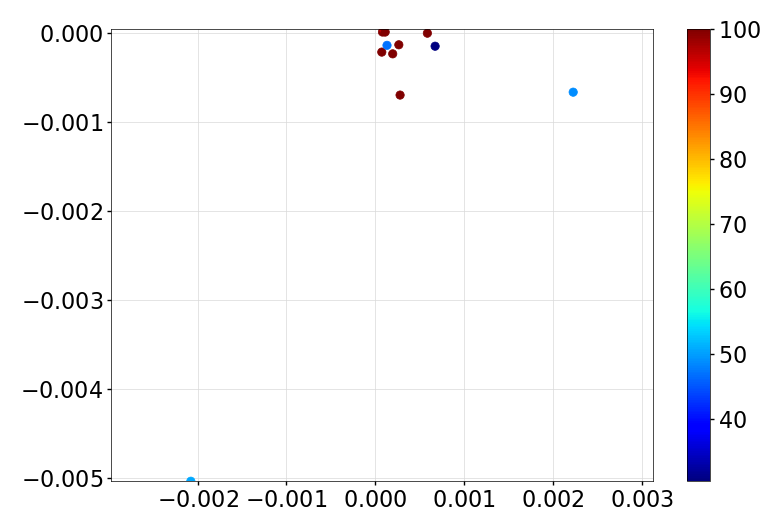

In [ ]:
groups = df.groupby(["lat", "lon", "method", "citation", "id"])

q = groups.max()

q = q[q.midpoint_depth > 30]
q = q[q.elevation > 1900]
q = q.sort_values(by="e1")
plt.scatter(q.e1, q.e2, c=q.midpoint_depth, cmap="jet", vmax=100)
plt.colorbar()
plt.axis("equal")
q

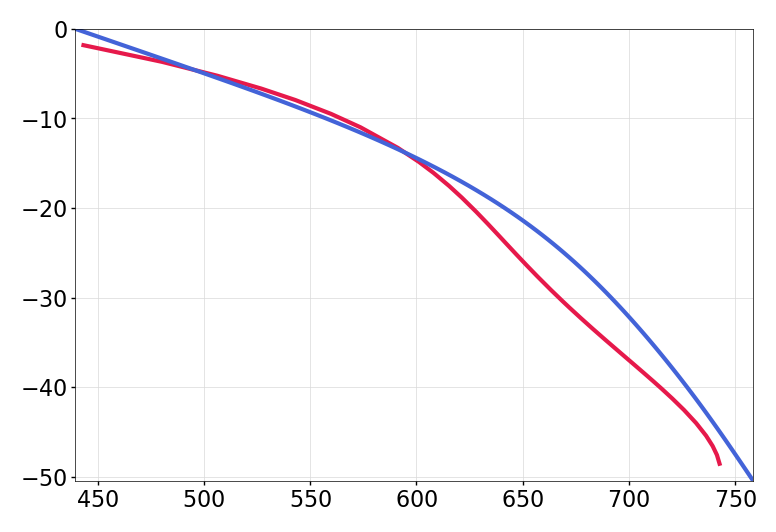

In [ ]:
rows = df[df["id"] == 696]
plt.plot(rows.density, -rows.midpoint_depth)
core = get_core(694)
core.plot()

-1.6006541918385784

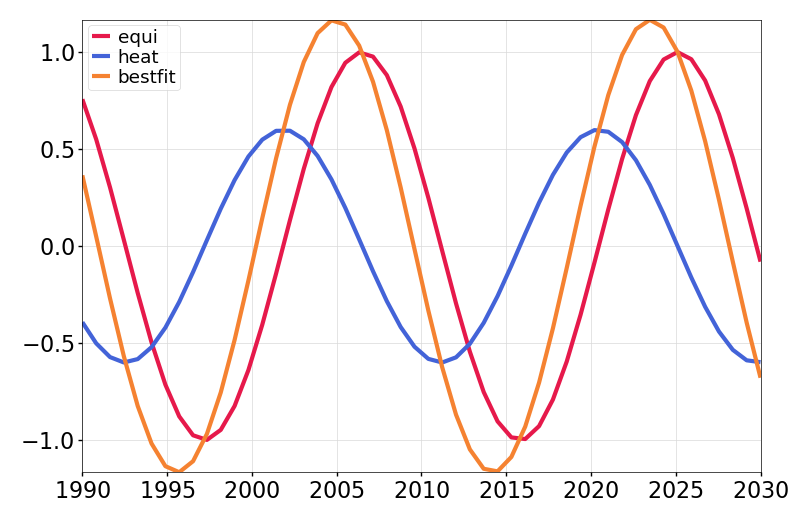

In [ ]:
t = np.linspace(1990, 2030)

C = -0.6
t0 = 2006.5
plt.plot(t, np.cos((t - t0) * 2 * np.pi / 18.61), label="equi")
plt.plot(t, C * np.sin((t - t0) * 2 * np.pi / 18.61), label="heat")
plt.plot(t, np.cos((t - t0) * 2 * np.pi / 18.61) + C * np.sin((t - t0) * 2 * np.pi / 18.61), label="bestfit")
plt.legend()
np.arctan2(C, 1) * 18.61 / (2 * np.pi)

In [ ]:
917 * 9.8 * (500 / 6000) * 100

74888.33333333333

In [ ]:
from grinsted_firn_model import *


def forward_model(sigma, a, b, A, B=0, n=3):
    p = -np.trace(sigma) / 3
    tau = sigma + p * np.eye(3)
    te2 = 0.5 * np.tensordot(tau, tau)
    se2 = a * te2 + (b * p**2) / 3
    phi = A * se2 ** ((n - 1) / 2) + B
    return phi * (a * tau - 2 * b * p * np.eye(3) / 9)


def inverse_model(e, a, b, A, n=3):
    ed = e - np.trace(e) * np.eye(3) / 3
    e_e2 = np.tensordot(ed, ed) / (2 * a) + 3 * np.trace(e) ** 2 / (4 * b)
    c = A ** (-1 / n) * e_e2 ** ((1 - n) / (2 * n))
    sigma = c * (ed / a + 3 * np.trace(e) * np.eye(3) / (2 * b))
    return sigma


def new_ezz(sigma_zz, a, b, A, e1=0, e2=0):
    if b == 0:
        return -e1 - e2
    r = 3 * a / 2 + 2 * b / 3
    p = (e1 + e2) * (3 * a / 2 - b / 3)
    Aszzab3 = A * (sigma_zz * a * b) ** 3
    k0 = -(p**3) + Aszzab3 * ((e1**2 - e1 * e2 + e2**2) / (3 * a) + (3 * (e1 + e2) ** 2) / (4 * b))
    k1 = -3 * r * p**2 + Aszzab3 * ((6 * e1 + 6 * e2) / (4 * b) - (e1 + e2) / (3 * a))
    k2 = -3 * p * r**2 + Aszzab3 * (1 / (3 * a) + 3 / (4 * b))
    k3 = -(r**3)
    rts = np.roots([k3, k2, k1, k0])
    rts = rts[np.isreal(rts)]  # & (np.sign(rts) == np.sign(sigma_zz))]
    if len(rts) == 0:
        return np.inf
    # diagnostic = 3 * (e1 + e2 + rts) ** 2 / (4 * b) + (
    #    e1**2 + e2**2 + rts**2 - ((e1 + e2 + rts) ** 2) / 3
    # ) / (
    #    2 * a
    # )  # this is the denominator -- has to be positive to make sense.
    # print(diagnostic, rts)

    return np.real(rts[0])  # TODO: figure out a better way to pick the correct root.


sigma_zz = -2e6
s1, s2 = 6e5, -6e5
sigma = np.diag(np.array([s1, s2, sigma_zz]))
a, b, A = a_fun(500), b_fun(500), A_fun(273.15 - 10)
a, b, A = 100, 50, 5e-25

e = forward_model(sigma, a, b, A, 0)
e1, e2 = e[0, 0], e[1, 1]
print(e)
sinv = inverse_model(e, a, b, A)

print(new_ezz(sigma_zz, a, b, A, e1, e2))
print(gagliardini_ezz(sigma_zz, a, b, A, e1, e2))
sigma, sinv

[[ 1.05389849e-02  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -6.54595336e-05  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -1.24373114e-02]]
-0.012437311385459535
-0.012437311385459553


(array([[  600000.,        0.,        0.],
        [       0.,  -600000.,        0.],
        [       0.,        0., -2000000.]]),
 array([[  600000.,        0.,        0.],
        [       0.,  -600000.,        0.],
        [       0.,        0., -2000000.]]))

In [ ]:
# dumb inversion.
from scipy.optimize import least_squares


f = lambda sxy: forward_model(np.diag([sxy[0], sxy[1], sigma_zz]), a, b, A, 0)
e0 = f([0, 0])[2, 2]
res = least_squares(
    lambda sxy: np.diag(f(sxy))[:-1] - np.array([e1, e2]),
    x0=np.array([0.0, 0.0]),
    x_scale=np.abs(sigma_zz),
    f_scale=np.abs(e0),
    tr_solver="exact",
    method="lm",
)
print(f(res.x)[2, 2], e[2, 2])

np.diag(f(res.x)) / np.array([e1, e2, e0])
res

-0.012437311385459528 -0.01243731138545953


     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 1.735e-18 -2.439e-19]
           x: [ 6.000e+05 -6.000e+05]
        cost: 1.534387469807717e-36
         jac: [[ 1.333e-08 -2.663e-09]
               [-2.663e-09  6.219e-09]]
        grad: [ 2.377e-26 -6.136e-27]
  optimality: 2.3773452735177576e-26
 active_mask: [0 0]
        nfev: 19
        njev: None

In [ ]:
a, b, A

(array(100.95763581), array(51.16728707), 4.917786136101778e-25)

In [ ]:
def iterative_root_of_cubic(k3, k2, k1, k0):
    # returns the real root
    # using the padé approximant method here:
    # https://math.stackexchange.com/questions/2863186/numerically-find-cubic-polynomial-roots-where-coefficients-widely-vary-in-magnit
    x = -k2 / k3  # initialize wher k1 and k0 are zero
    dx = np.inf
    while np.abs(dx) > (np.abs(x) / 1e8 + 1e-10):
        f = k3 * x**3 + k2 * x**2 + k1 * x + k0
        if f == 0:
            return x
        fp = 3 * k3 * x**2 + 2 * k2 * x + k1
        fpp = 2 * k2 + 6 * k3 * x
        dx = 0.5 * f * (f * fpp - 2 * fp**2) / (f**2 + fp**3 - f * fp * fpp)
        x = x + dx
    return x


def real_root(k3, k2, k1, k0):
    rts = np.roots([k3, k2, k1, k0])
    rts = rts[np.isreal(rts)]  # & (np.sign(rts) == np.sign(sigma_zz))]
    return np.real(rts[0])


def closed_form_cubic_root(k3, k2, k1, k0):
    # https://medium.com/@mephisto_Dev/solving-cubic-equation-using-cardanos-method-with-python-9465f0b92277
    p = (3 * k3 * k1 - k2**2) / (3 * k3**2)
    q = (2 * k2**3 - 9 * k3 * k2 * k1 + 27 * k3**2 * k0) / (27 * k3**3)
    delta = q**2 / 4 + p**3 / 27
    u = np.cbrt(-q / 2 + np.sqrt(delta))
    v = np.cbrt(-q / 2 - np.sqrt(delta))
    return u + v - k2 / (3 * k3)


k3, k2, k1, k0 = 5, -3, 2, 500
import timeit

N = 1000
tcb = timeit.timeit(lambda: real_root(k3, k2, k1, k0), number=N)
tit = timeit.timeit(lambda: iterative_root_of_cubic(k3, k2, k1, k0), number=N)
tclosed = timeit.timeit(lambda: closed_form_cubic_root(k3, k2, k1, k0), number=N)
tcb, tit, tclosed
real_root(k3, k2, k1, k0), closed_form_cubic_root(k3, k2, k1, k0)

(-4.422475185047195, -4.422475185048342)

2.220446049250313e-06

ModuleNotFoundError: No module named 'sympy'

50 [0.21200399 0.48690842] 0.282637848313397
100 [0.17422073 0.44219309] 0.292218334561392
150 [0.1766271  0.37256864] 0.23125527131399523
200 [0.18630728 0.33802167] 0.20934382974035443
250 [0.20146642 0.31127915] 0.1955969083300442
300 [0.0984781  0.25979812] 0.19360788901604364
350 [0.07528451 0.26672553] 0.2010926237251128
400 [0.06497455 0.27244461] 0.21103571539204893
50 [0.15510405 0.38727777] 0.33027429778632655
100 [0.13894878 0.43180133] 0.3679386507797635
150 [0.13498263 0.36577832] 0.32553409717213383
200 [0.1265122  0.31612292] 0.29635232367027303
250 [0.11795053 0.28379965] 0.27741713078957864
300 [0.10984828 0.26227513] 0.2630141772220337
350 [0.10223145 0.24678665] 0.24989178509839502
400 [0.09518549 0.23474173] 0.23691779840850774
50 [0.46005715 0.73853707] 0.5597867077593215
100 [0.43795344 0.69879766] 0.4550557962117603
150 [0.43554713 0.66014142] 0.39347015351905684
200 [0.43462129 0.6249838 ] 0.3446506363901676
250 [0.43416289 0.59035871] 0.29808841792350954
300 [0

(array([[-4.85450614,  4.49936164],
        [-4.84251474,  4.63928886],
        [-4.68592651,  4.77781184],
        [-3.82963067,  3.4560469 ]]),
 array([-0.3551445 , -0.20322588,  0.09188533, -0.37358376]))

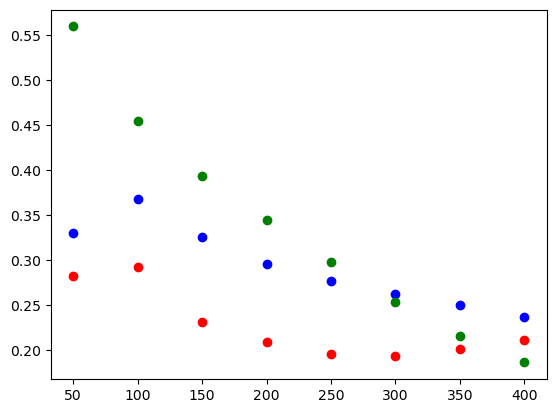

In [ ]:
from maplookup import get_strainrate
import numpy as np
import matplotlib.pyplot as plt

lats = np.array([75.6206, 75.59975, 75.5682717])
lons = np.array([-35.971, -35.51035, -35.58572833])

smoothings = np.array([50, 100, 150, 200, 250, 300, 350, 400])
colors = ["red", "blue", "green", "orange"]
cix = 0
for lat, lon in zip(lats, lons):
    q = np.empty((4, 2))
    for smoothing in smoothings:
        q[0, :] = get_strainrate(lat, lon=lon, source="tsx", smoothing_sigma=smoothing, return_eigen_strainrate=True)
        q[1, :] = get_strainrate(lat, lon=lon, source="dtu", smoothing_sigma=smoothing, return_eigen_strainrate=True)
        q[2, :] = get_strainrate(lat, lon=lon, source="measures", smoothing_sigma=smoothing, return_eigen_strainrate=True)
        q[3, :] = get_strainrate(lat, lon=lon, source="its-live", smoothing_sigma=smoothing, return_eigen_strainrate=True)
        print(smoothing, np.std(q, axis=0) * 1000, np.std(np.sum(q, axis=1)) * 1000)
        plt.plot(smoothing, np.std(np.sum(q, axis=1)) * 1000, "o", color=colors[cix])
    cix += 1
q * 1000, np.sum(q, axis=1) * 1000

In [ ]:
import numpy as np

lat, lon = 75.5682717, -35.58572833
lat, lon = 75.5682717, -35.58572833  # s51
# lat,lon = 75.6206, -35.971 #s6

get_strainrate(lat, lon=lon, smoothing_sigma=150, return_eigen_strainrate=True)

array([-0.00501732,  0.00465629])

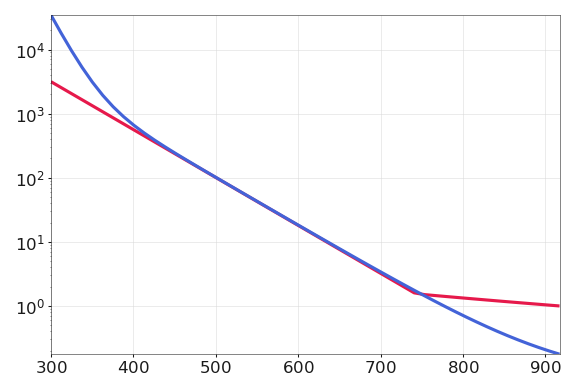

In [ ]:
import grinsted_firn_model
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")

rho = np.linspace(300, 917)

plt.semilogy(rho, grinsted_firn_model.a_fun(rho))


def afun2(rho):
    # params:
    icelimit = 0.1
    rhat = rho / 917
    duvacrow = (1 + (2 / 3) * (1 - rhat)) * (rhat ** (-1.5))
    mainslope = -15.78652 / 917  # zwinger main slope
    a600 = grinsted_firn_model.a_fun(600)

    return icelimit * duvacrow + a600 * np.exp(mainslope * (rho - 600)) * (1 + 10 * np.exp(-0.04 * (rho - 300)))


# parameters = icelimit, v600, mainslope, m300, surfslope

plt.plot(rho, afun2(rho))

In [52]:
917 / 2

458.5

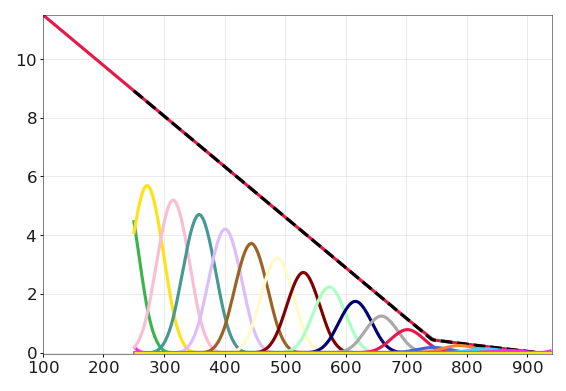

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")
from scipy.interpolate import BSpline, make_lsq_spline, make_interp_spline
from grinsted_firn_model import a_fun

rho = np.linspace(300, 917, 200)
k = 3  # cubic spline


rho = np.linspace(100, 917, 20)
spl = make_interp_spline(rho, np.log(a_fun(rho)), k=k, bc_type=([(1, 0.0)], [(1, 0.0)]))

plt.plot(rho, spl(rho))

rho = np.linspace(250, 940, 200)
plt.plot(rho, np.log(a_fun(rho)), "k--")

c = spl.c
for ii in range(len(c)):
    spl.c = c * 0
    spl.c[ii] = c[ii]
    plt.plot(rho, spl(rho))

In [ ]:
c = np.arange(4)
np.

(array([0, 1]), array([2, 3]))

In [21]:
print(np.log(a_fun(rho)).shape)  # What is this?

(200,)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")
rhoterm = 917 - 916
dt = 24 * 365 * 60 * 60
DrhoDt = 1 / dt
917 - np.exp(np.log(rhoterm + 1) - DrhoDt * dt / (rhoterm + 1)) + 1

np.float64(917.9865241060019)

In [ ]:
(DrhoDt < 0)

np.float64(-1.0)